# Online Forum Multi-Label Communicative Type Classification

Casual online forum comments written in Bahasa Melayu, English, and Manglish from Lowyat Kopitiam are classified according to the communicative purpose expressed by the user.


# The 6 Categories

- **Inquiry**: Questions, seeking help, recommendations, or troubleshooting.
- **Complaint**: Venting frustration, complaining about bad service, high prices, or problems.
- **Opinion**: Personal viewpoints, beliefs, reviews, or arguments.
- **Information**: Objective facts, news, official updates, guides, or links.
- **Expressive**: Jokes, laughing, memes, greetings, or casual banter.
- **Spam**: Unwanted promotional links, referral links, or automated bot posts.

A single forum comment may serve multiple communicative purposes; therefore, **Multi-Label Classification** is used.


The raw Lowyat forum records are obtained from the Malaysia AI Lowyat Kopitiam dataset:

https://huggingface.co/datasets/malaysia-ai/crawl-lowyat/resolve/main/kopitiam.json

Generative AI is used to assist in classifying the records according to the six communicative categories. The resulting annotated dataset is stored in `dataset.csv`.

# 0.0 Environment Setup & Configuration
The required dependencies are installed and non-critical library warnings are suppressed for clean notebook execution.

## 0.1 Install Required Libraries

The project dependencies are specified in `requirements.txt`.

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 0.2 Suppress Warnings
Configure warning filters to suppress non-critical deprecation and regex notifications from external libraries for clean notebook execution.

In [2]:
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 1.0 Pre-processing: Structural Cleaning & Basic Normalization

This stage inspects the dataset, removes structural noise, masks highly variable entities, and performs basic text normalization before linguistic processing.

## 1.1 Initial Dataset Inspection
The annotated dataset is loaded to examine the total number of records and the available fields before preprocessing.

In [3]:
import pandas as pd

data = pd.read_csv("dataset.csv", encoding="utf-8")

print("Total rows in the dataset:", data.shape[0])

print("\nDataset columns:")
print(list(data.columns))

print("\nFirst 5 rows of the dataset:")
display(data.head(5))

print("\nLast 5 rows of the dataset:")
display(data.tail(5))

Total rows in the dataset: 99106

Dataset columns:
['id', 'text', 'Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']

First 5 rows of the dataset:


,id,text,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,1,Konfem puting hitam hehhe,0,0,0,0,1,0
1,2,the feast starts now!,0,0,0,0,1,0
2,3,Shake shake 5pm\n\nhttps://games.shopee.com.my...,0,0,0,1,0,1
3,4,Situasi dlm keta\n\nKau : padu betul\n\nDia : ...,0,0,0,0,1,0
4,5,currently he is playing for india?\nwooooh.......,1,0,0,0,1,0



Last 5 rows of the dataset:


,id,text,Inquiry,Complaint,Opinion,Information,Expressive,Spam
99101,99102,Sendiri bodo no wonder miskin kek,0,0,1,0,1,0
99102,99103,Removed\n\nThis post has been edited by Pretty...,0,0,0,0,0,0
99103,99104,"QUOTE(Mr Mercedes @ Mar 10 2023, 05:58 PM)Nobo...",0,0,1,1,0,0
99104,99105,Topkek dah berapa bulan masih x launch.,0,1,1,0,1,0
99105,99106,cny now ka?,1,0,0,0,0,0


## 1.2 Quote Block & Signature Removal

Forum quote blocks and Lowyat edit signatures are removed to prevent quoted content and forum metadata from being interpreted as part of the current user's communicative intent.

In [4]:
import re

QUOTE_REGEX = re.compile(
    r"QUOTE\s*\([\s\S]*?\)|\[QUOTE[\s\S]*?\[/QUOTE\]", re.IGNORECASE
)
EDIT_SIG_REGEX = re.compile(r"This post has been edited by.*?(?=\n|$)", re.IGNORECASE)


def remove_quotes(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return QUOTE_REGEX.sub("", text)


def remove_lowyat_edit_signatures(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return EDIT_SIG_REGEX.sub("", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(remove_quotes)

print(
    "Number of rows affected by quote removal:", (original_texts != data["text"]).sum()
)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(remove_lowyat_edit_signatures)

print(
    "Number of rows affected by Lowyat edit signature removal:",
    (original_texts != data["text"]).sum(),
)

Number of rows affected by quote removal: 44778
Number of rows affected by Lowyat edit signature removal: 8036


IN:  QUOTE(john @ 12 jan 2024) anyone selling 2nd hand iphone under RM800?? This post has been edited by john: 15 aug 2024
OUT: anyone selling 2nd hand iphone under RM800??

## 1.3 Special Element Masking

Specific entities are replaced with generic placeholder tokens.

- URLs & Links: `https://...` $\rightarrow$ `URLTOKEN`
- Phone Numbers: `012-3456789, +6017...` $\rightarrow$ `PHONETOKEN`
- Prices / Currency: `RM150, $20` $\rightarrow$ `PRICETOKEN`
- Timestamps: `02:30 PM, 14:00` $\rightarrow$ `TIMETOKEN`
- Dates: `2020-01-01, 01feb` $\rightarrow$ `DATETOKEN`

Placeholders keep the important information without filling the vocabulary with too many unique words.

### 1.3.1 Mask URL & Links

Web addresses and domain links are replaced with `URLTOKEN`.

In [5]:
URL_REGEX = re.compile(
    r"(https?://[^\s]+|www\.[^\s]+|[a-zA-Z0-9-]+\.[a-zA-Z]{2,24}[^\s]*)", re.IGNORECASE
)


def mask_urls(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return URL_REGEX.sub(" URLTOKEN ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(mask_urls)

print("Total rows affected by masking URLs:", (original_texts != data["text"]).sum())

Total rows affected by masking URLs: 10776


IN:  Check www.example.com 
OUT: Check  URLTOKEN  

### 1.3.2 Mask Phone Numbers

Malaysian phone numbers are detected using the `phonenumbers` library and replaced with `PHONETOKEN`.

In [6]:
import phonenumbers


def mask_phone_numbers(text, default_region="MY"):
    if not isinstance(text, str) or not text.strip():
        return ""

    matches = list(phonenumbers.PhoneNumberMatcher(text, default_region))

    # Replace from right to left so that earlier character positions remain valid
    for match in reversed(matches):
        text = text[: match.start] + " PHONETOKEN " + text[match.end :]

    return text


original_texts = data["text"].copy()
data["text"] = data["text"].apply(mask_phone_numbers)

print(
    "Total rows affected by masking phone numbers:",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking phone numbers: 100


IN:  Contact 012-3456789
OUT: Contact  PHONETOKEN

### 1.3.3 Mask Prices

Global and regional currency expressions are converted into `PRICETOKEN`.

In [7]:
from price_parser.parser import CURRENCY_SYMBOLS

all_symbols = set(CURRENCY_SYMBOLS)

# Localized currency representations commonly used in regional forums
all_symbols.update(["RM", "rm", "MYR", "myr", "S$", "A$", "HK$", "NT$"])

print("All currency symbols to be masked:", all_symbols)

All currency symbols to be masked: {'Bds$', 'Pta', 'UM', 'zł', 'din.', '£', 'S/.', 'Db', 'MURs', 'J$', 'Ikr', 'OMR', 'KZT', 'C$', 'KD', 'SDG', 'rm', 'myr', 'Nkr', 'WS$', 'MDL', 'SKK', 'SR', 'R', 'RD$', '₪', 'DA', 'Kz', '$U', 'XBC', 'MGA', '₩', 'kr', 'QR', 'SIT', 'CFP', 'CUC$', 'FG', 'GTQ', 'öS', 'Ft', 'IQD', 'XUA', 'KHR', 'BWP', 'TT$', 'XXX', '₫', '$', 'руб', 'RUB', 'MMK', 'CFA', 'N$', 'CV$', 'AED', 'Fdj', 'XDR', 'SSP', 'USh', 'AU$', '€', 'XAU', 'Z$', 'FIM', 'MAD', 'BGN', 'CL$', 'T$', 'MYR', 'AR$', 'XTS', 'HK$', 'Nu.', 'BD', 'RON', 'Afl.', 'F', 'ƒ', 'man.', 'UF', 'G', 'AMD', 'Kč', 'CHF', 'Ls', 'Br', 'MOP$', 'Nfk', 'K', 'DT', 'JD', '¥', '₨', 'R$', 'NZ$', 'Sucre', '₦', 'A$', 'RWF', 'BN$', 'SLRs', 'GH₵', 'Lm', 'UYI', 'CA$', 'IRR', 'B/.', 'XPD', 'Rp', 'LB£', 'CYP', 'MK', '-', 'MX$', 'GRD', 'LD', 'Dkr', 'лв', 'PKRs', 'XAG', 'EGP', 'XBD', 'TSh', 'L', 'Lt', 'Skr', 'TL', 'Rs', 'Bs.F.', 'Tk', 'NPRs', 'FCFA', 'NT$', 'BZ$', 'fl.', '₲', 'CN¥', 'Af', 'MKD', 'kn', 'SY£', 'MTn', '₴', 'D', 'Ksh', 'RM'

In [8]:
# Filter out potentially dangerous single alphabetic letters such as 'w', 's', or 'k'

safe_symbols = {
    symbol for symbol in all_symbols if len(symbol) > 1 or not symbol.isalpha()
}

escaped_symbols = [
    re.escape(symbol) for symbol in sorted(safe_symbols, key=len, reverse=True)
]

DYNAMIC_CURRENCY_PATTERN = "|".join(escaped_symbols)
PRICE_REGEX = re.compile(
    rf"(?:(?:\b|\s)"
    rf"(?:{DYNAMIC_CURRENCY_PATTERN})"
    rf"\s*\d+(?:[\.,]\d+)?\b|"
    rf"\b\d+(?:[\.,]\d+)?\s*"
    rf"(?:{DYNAMIC_CURRENCY_PATTERN})\b)",
    re.IGNORECASE,
)


def mask_prices(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return PRICE_REGEX.sub(" PRICETOKEN ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(mask_prices)

print("Total rows affected by masking prices:", (original_texts != data["text"]).sum())

Total rows affected by masking prices: 8845


IN:  anyone selling 2nd hand iphone under RM800??
OUT: anyone selling 2nd hand iphone under PRICETOKEN ?

### 1.3.4 Mask Timestamps

12-hour and 24-hour timestamp expressions are converted into `TIMETOKEN`.

In [9]:
TIME_REGEX = re.compile(
    r"\b(?:1[0-2]|0?[1-9]):[0-5][0-9](?::[0-5][0-9])?\s?(?:[AaPp][Mm])?\b"   # 12hr, colon
    r"|\b(?:[01]?[0-9]|2[0-3]):[0-5][0-9](?::[0-5][0-9])?\b"                 # 24hr, colon
    r"|\b(?:1[0-2]|0?[1-9])\.[0-5][0-9](?:\.[0-5][0-9])?\s?[AaPp][Mm]\b",    # 12hr, dot — AM/PM required
    re.IGNORECASE
)


def mask_times(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    return TIME_REGEX.sub(" TIMETOKEN ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(mask_times)

print("Total rows affected by masking timestamps:", (original_texts != data["text"]).sum())

Total rows affected by masking timestamps: 527


IN:  ...meeting at 3.30pm on 15/08/2024...
OUT: ...meeting at  TIMETOKEN  on 15/08/2024...

### 1.3.5 Mask Date

Date expressions are replaced with `DATETOKEN` to prevent specific calendar references from polluting the vocabulary with high-IDF noise terms.

In [10]:
DAY_TWODIGIT = r"(?:0[1-9]|[12][0-9]|3[01])"  
MONTH = r"(?:0?[1-9]|1[0-2])"

DATE_REGEX = re.compile(
    # dd/mm/yyyy or dd-mm-yyyy or dd/mm or dd-mm
    rf"\b{DAY_TWODIGIT}[-/]{MONTH}(?:[-/](?:\d{{2}}|\d{{4}}))?\b"                             
    r"|"
    # dd month yyyy or dd month or ddmonth e.g. 01feb, 1 Feb 2024, 01Feb24
    r"\b[0-3]?[0-9]\s?(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\w*(?:\s+\d{2,4})?\b"
    r"|"
    # month dd yyyy or month dd e.g. Nov 9 2021, February 1 2024
    r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\w*\s+[0-3]?[0-9](?:\s+\d{2,4})?\b"
    r"|"
    # yyyy/mm/dd or yyyy-mm-dd
    r"\b\d{4}[-/][0-1]?[0-9][-/][0-3]?[0-9]\b",
    re.IGNORECASE
)

def mask_dates(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return DATE_REGEX.sub(" DATETOKEN ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(mask_dates)

print(
    "Total rows affected by masking dates:",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking dates: 1395


## 1.4 Emoji Conversion

Convert emojis directly into space-separated words

In [11]:
import emoji


def convert_emojis(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return emoji.demojize(text).replace(":", " ").replace("_", " ")


original_texts = data["text"].copy()
data["text"] = data["text"].apply(convert_emojis)

print(
    "Total rows affected by emoji conversion:", (original_texts != data["text"]).sum()
)

Total rows affected by emoji conversion: 7063


IN:  DATETOKEN  😂😂 i tak nak overprice one...
OUT: DATETOKEN   face with tears of joy face with tears of joy i tak nak overprice one...

## 1.5 Lowercasing

All characters are converted to lowercase to reduce vocabulary variation caused by capitalization.

In [12]:
def to_lower(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return text.lower()


data["text"] = data["text"].apply(to_lower)

IN:  PRICETOKEN, PHONETOKEN, URLTOKEN, TIMETOKEN, DATETOKEN
OUT: pricetoken, phonetoken, urltoken, timetoken, datetoken

## 1.6 Smart Apostrophe Normalization

Normalize typographic smart apostrophes to standard ASCII `'` before applying `strip_non_latin` to prevent words like `don’t` from turning into `dont`

In [13]:
SMART_APOSTROPHE_REGEX = re.compile(r"['\u2018\u2019\u201a\u201b\u2032\u2035`]")


def normalize_apostrophes(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return SMART_APOSTROPHE_REGEX.sub("'", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(normalize_apostrophes)

print(
    "Total rows affected by apostrophe normalization:",
    (original_texts != data["text"]).sum(),
)

Total rows affected by apostrophe normalization: 2979


IN: can’t
OUT: can't

## 1.7 Filter Non-Latin Characters

Non-ASCII character sequences are removed to focus the corpus on the intended English, Bahasa Melayu, and Manglish content.

In [14]:
NON_LATIN_REGEX = re.compile(r"[^\x00-\x7F]+")


def strip_non_latin(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return NON_LATIN_REGEX.sub("", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(strip_non_latin)

print(
    "Total rows affected by stripping non-Latin characters:",
    (original_texts != data["text"]).sum(),
)

Total rows affected by stripping non-Latin characters: 6267


IN: nice phone 你好
OUT: nice phone

## 1.8 Elongated Character & Symbol Reduction

Characters repeated three or more times are reduced to two occurrences, while consecutive punctuation marks are reduced to a smaller representation.

In [15]:
REPEAT_CHAR_REGEX = re.compile(r"(.)\1{2,}", re.IGNORECASE)
REPEAT_PUNCT_REGEX = re.compile(r"([!?.])\1+")


def reduce_elongated(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    text = REPEAT_CHAR_REGEX.sub(r"\1\1", text)
    text = REPEAT_PUNCT_REGEX.sub(r"\1", text)

    return text.strip()


original_texts = data["text"].copy()
data["text"] = data["text"].apply(reduce_elongated)

print(
    "Total rows affected by elongation reduction:",
    (original_texts != data["text"]).sum(),
)

Total rows affected by elongation reduction: 40025


IN:  ...RM800?? ... scammer looool!!!
OUT: ...pricetoken ? ... scammer lool!

# 2.0 Pre-processing: Tokenization & Slang Normalization

This stage performs sentence-level processing and informal-language normalization before word tokenization. Multi-word slang expressions are intentionally normalized before word tokenization so that phrase boundaries are retained.

## 2.1 Sentence Tokenization

Sentence boundaries are identified using NLTK's `sent_tokenize`.

### 2.1.1 Initialize NLTK Sentence Tokenizer

In [16]:
import nltk

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download("punkt", quiet=True)


try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    print("Downloading NLTK punkt_tab tokenizer...")
    nltk.download("punkt_tab", quiet=True)

### 2.1.2 Tokenize Sentences

In [17]:
from nltk.tokenize import sent_tokenize


def tokenize_sentences(text):
    if not isinstance(text, str) or not text.strip():
        return []

    return sent_tokenize(text)


tokenized_sentences = data["text"].apply(tokenize_sentences)
total_sentences = tokenized_sentences.apply(len).sum()

print("Total sentences extracted across dataset:", total_sentences)

Total sentences extracted across dataset: 290858


## 2.2 Pre-built Internet Slang Normalization

The English slang dictionary is obtained from:
https://github.com/cbaziotis/ekphrasis/blob/master/ekphrasis/dicts/noslang/slangdict.py

The dictionary is saved locally as `slangdict.json`.
Both single-word and multi-word slang expressions are normalized.`

In [18]:
import json

english_slangdict = json.load(open("slangdict.json", "r", encoding="utf-8"))

print("Total English Slang entries:", len(english_slangdict))
print("Examples of English Slang entries:")
for k, v in list(english_slangdict.items())[:5]:
    print("  ", k, "->", v)

Total English Slang entries: 5439
Examples of English Slang entries:
   k4u -> Kiss for you
   67 -> unknown
   07734 -> hello
   0day -> software illegally obtained before it was released
   0noe -> Oh No


### 2.2.1 Load English Slang Dictionary

In [19]:
import json

with open("slangdict.json", "r", encoding="utf-8") as file:
    english_slangdict = json.load(file)

print("Total English Slang entries:", len(english_slangdict))
print("Examples of English Slang entries:")
for key, value in list(english_slangdict.items())[:5]:

    print(" ", key, "->", value)

Total English Slang entries: 5439
Examples of English Slang entries:
  k4u -> Kiss for you
  67 -> unknown
  07734 -> hello
  0day -> software illegally obtained before it was released
  0noe -> Oh No


### 2.2.2 Normalize English Slang

In [20]:
EN_SLANG_MAP = {
    str(key).lower(): str(value) for key, value in english_slangdict.items() if key
}

en_multi_word_keys = [key for key in EN_SLANG_MAP if " " in key]
en_multi_word_keys.sort(key=len, reverse=True)

EN_MULTI_WORD_REGEX = None
if en_multi_word_keys:
    EN_MULTI_WORD_REGEX = re.compile(
        r"\b(" + "|".join(re.escape(key) for key in en_multi_word_keys) + r")\b",
        flags=re.IGNORECASE,
    )

EDGE_PUNCT_REGEX = re.compile(r"^([^\w]*)(.*?)([^\w]*)$")


def normalize_slang_bulletproof(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    if EN_MULTI_WORD_REGEX:
        text = EN_MULTI_WORD_REGEX.sub(
            lambda match: EN_SLANG_MAP.get(match.group(0).lower(), match.group(0)), text
        )

    tokens = text.split()
    normalized_tokens = []

    for token in tokens:
        lower_token = token.lower()
        if lower_token in EN_SLANG_MAP:
            normalized_tokens.append(EN_SLANG_MAP[lower_token])
            continue

        match = EDGE_PUNCT_REGEX.match(token)
        if match:
            prefix, core, suffix = match.groups()
            lower_core = core.lower()
            if lower_core in EN_SLANG_MAP:
                normalized_tokens.append(f"{prefix}{EN_SLANG_MAP[lower_core]}{suffix}")
                continue

        normalized_tokens.append(token)

    return " ".join(normalized_tokens)


normalized_english_sentences = tokenized_sentences.apply(
    lambda sentence_list: [
        normalize_slang_bulletproof(sentence) for sentence in sentence_list
    ]
)

sentences_affected = sum(
    original != normalized
    for original_list, normalized_list in zip(
        tokenized_sentences, normalized_english_sentences
    )
    for original, normalized in zip(original_list, normalized_list)
)

print("Total sentences affected by English slang normalization:", sentences_affected)

Total sentences affected by English slang normalization: 104693


IN:  ...some ppl still dont believe, scammer lool!
OUT: ...some people still do not believe, scammer laughing out loud!

## 2.3 Malay Slang Normalization

The Malay slang dictionary is obtained from:
https://data.mendeley.com/datasets/mgv2n2vcb9/3/files/a7b86a2f-1175-4ff0-b813-d95218534cd4

The downloaded resource is saved as `malayslangdict.json`.
Another custom dictionary is stored in `custom_malay_slang.json`.

These resources are merged to normalize informal Malay and Manglish expressions.

### 2.3.1 Load Malay Slang Dictionaries

In [21]:
with open("malayslangdict.json", "r", encoding="utf-8") as file:
    malay_slang_1 = json.load(file)


with open("custom_malay_slang.json", "r", encoding="utf-8") as file:
    malay_slang_2 = json.load(file)


malay_slangdict = {**malay_slang_1, **malay_slang_2}

print("Total Malay Slang entries:", len(malay_slangdict))
print("Examples of Malay Slang entries:")
for key, value in list(malay_slangdict.items())[:5]:
    print(" ", key, "->", value)

Total Malay Slang entries: 1476
Examples of Malay Slang entries:
  2 -> itu
  6be -> nombor
  abeh -> habis
  abes -> habis
  abih -> habis


### 2.3.2 Normalize Malay Slang

In [22]:
MY_SLANG_MAP = {
    str(key).lower(): str(value)
    for key, value in malay_slangdict.items()
    if key and str(key).lower() != str(value).lower()
}

my_multi_word_keys = [key for key in MY_SLANG_MAP if " " in key]
my_multi_word_keys.sort(key=len, reverse=True)

MY_MULTI_WORD_REGEX = None
if my_multi_word_keys:
    MY_MULTI_WORD_REGEX = re.compile(
        r"\b(" + "|".join(re.escape(key) for key in my_multi_word_keys) + r")\b",
        flags=re.IGNORECASE,
    )


def normalize_malay_slang_bulletproof(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    if MY_MULTI_WORD_REGEX:
        text = MY_MULTI_WORD_REGEX.sub(
            lambda match: MY_SLANG_MAP.get(match.group(0).lower(), match.group(0)), text
        )

    tokens = text.split()
    normalized_tokens = []

    for token in tokens:
        lower_token = token.lower()
        if lower_token in MY_SLANG_MAP:
            normalized_tokens.append(MY_SLANG_MAP[lower_token])
            continue

        match = EDGE_PUNCT_REGEX.match(token)
        if match:
            prefix, core, suffix = match.groups()
            lower_core = core.lower()
            if lower_core in MY_SLANG_MAP:
                normalized_tokens.append(f"{prefix}{MY_SLANG_MAP[lower_core]}{suffix}")
                continue

        normalized_tokens.append(token)

    return " ".join(normalized_tokens)


normalized_malay_sentences = normalized_english_sentences.apply(
    lambda sentence_list: [
        normalize_malay_slang_bulletproof(sentence) for sentence in sentence_list
    ]
)

sentences_affected = sum(
    original != normalized
    for original_list, normalized_list in zip(
        normalized_english_sentences, normalized_malay_sentences
    )
    for original, normalized in zip(original_list, normalized_list)
)

print("Total sentences affected by Malay slang normalization:", sentences_affected)

Total sentences affected by Malay slang normalization: 116021


IN:  ...i tak nak overprice one...
OUT: ...i tidak mahu overprice one...

## 2.4 Contraction Normalization

English contractions are expanded using the `contractions` library before word tokenization.
This prevents forms such as `don't` from being passed to NLTK as tokenizer-specific fragments such as `do` and `n't`.

In [23]:
import contractions


def normalize_contractions(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return contractions.fix(text)


normalized_contraction_sentences = normalized_malay_sentences.apply(
    lambda sentence_list: [
        normalize_contractions(sentence) for sentence in sentence_list
    ]
)

sentences_affected = sum(
    original != normalized
    for original_list, normalized_list in zip(
        normalized_malay_sentences, normalized_contraction_sentences
    )
    for original, normalized in zip(original_list, normalized_list)
)

print("Total sentences affected by contraction normalization:", sentences_affected)

Total sentences affected by contraction normalization: 37974


IN:  ...i can't believe...
OUT: ...i cannot believe...

## 2.5 Word Tokenization

Normalized sentences are divided into individual word and punctuation tokens using NLTK's `word_tokenize`.

Word tokenization is deliberately placed after slang normalization because the slang dictionaries contain multi-word expressions.

In [24]:
from nltk.tokenize import word_tokenize


def tokenize_words(sentence_text):
    if not isinstance(sentence_text, str) or not sentence_text.strip():
        return []

    return word_tokenize(sentence_text)


word_tokenized_posts = normalized_contraction_sentences.apply(
    lambda sentence_list: [tokenize_words(sentence) for sentence in sentence_list]
)


total_words = sum(len(sentence) for post in word_tokenized_posts for sentence in post)

print("Total word tokens generated across dataset:", total_words)

Total word tokens generated across dataset: 3815144


IN:  "contact phonetoken or check urltoken meeting at timetoken on datetoken face with tears
      of joy face with tears of joy i tidak mahu overprice one, i cannot believe some people
      still do not believe, scammer laughing out loud!"
OUT: ['contact','phonetoken','or','check','urltoken','meeting','at','timetoken','on','datetoken',
      'face','with','tears','of','joy','face','with','tears','of','joy','i','tidak','mahu',
      'overprice','one',',','i','cannot','believe','some','people','still','do','not','believe',
      ',','scammer','laughing','out','loud','!']

## 2.6 Punctuation Filtering

Uninformative punctuation is removed while preserving `?` and `!` as potentially useful communicative signals. Entity placeholders are also preserved.

In [25]:
KEEP_PUNCTUATION = {"?", "!"}
ENTITY_TOKENS = {"urltoken", "pricetoken", "phonetoken", "timetoken", "datetoken"}


def filter_tokens(post_sentences):
    cleaned_post = []

    for sentence in post_sentences:
        cleaned_sentence = []

        for token in sentence:
            token_str = token.strip().lower()

            # Preserve entity placeholders
            if token_str in ENTITY_TOKENS:
                cleaned_sentence.append(token_str)

            # Preserve regular word tokens
            elif token_str.isalnum():
                cleaned_sentence.append(token_str)

            # Preserve communicative punctuation
            elif token_str in KEEP_PUNCTUATION:
                cleaned_sentence.append(token_str)

        if cleaned_sentence:
            cleaned_post.append(cleaned_sentence)

    return cleaned_post


filtered_punct_posts = word_tokenized_posts.apply(filter_tokens)

print("Total posts after punctuation filtering:", len(filtered_punct_posts))

Total posts after punctuation filtering: 99106


IN:  [...,'believe',',','scammer','laughing','out','loud','!']
OUT: [...,'believe','scammer','laughing','out','loud','!']

# 3.0 Pre-processing: Language-Aware Morphological Processing

This stage identifies the language of each token, applies language-specific morphological processing, filters normalized stopwords, and produces the final token representation.

## 3.1 Dictionary Lookups & Language Identification

Each token is classified as `TAG`, `PUNCT`, `MALAY`, `ENGLISH`, or `UNKNOWN`.

In [26]:
from malaya.dictionary import is_malay, is_english

ENTITY_TOKENS = {"urltoken", "pricetoken", "phonetoken", "timetoken", "datetoken"}


def classify_word_lang(token):
    token = token.lower()

    if token in ENTITY_TOKENS:
        return "TAG"

    if token in {"?", "!"}:
        return "PUNCT"

    if is_malay(token):
        return "MALAY"

    if is_english(token):
        return "ENGLISH"

    return "UNKNOWN"


def classify_post_lang(post):
    return [
        [(token, classify_word_lang(token)) for token in sentence] for sentence in post
    ]


classified_lang_posts = filtered_punct_posts.apply(classify_post_lang)

IN:  ['anyone','selling','2nd','hand','iphone','under','pricetoken','?']
OUT: [('anyone','ENGLISH'), ('selling','ENGLISH'), ('2nd','UNKNOWN'), ('hand','ENGLISH'),
      ('iphone','UNKNOWN'), ('under','ENGLISH'), ('pricetoken','TAG'), ('?','PUNCT')]

## 3.2 Stemming & Lemmatization


We apply cross-lingual morphological normalization to reduce words to their base root forms using Sastrawi for Malay and WordNet for English.

### 3.2.1 Initialize Malaya Sastrawi Stemmer


We initialize the Sastrawi Malay stemmer from the `malaya.stem` library to remove Malay prefixes and suffixes (affixes).

In [27]:
from malaya.stem import sastrawi

# Initialize Malaya Sastrawi Stemmer
sastrawi_stemmer = sastrawi()

# Quick test
print("mementingkan ->", sastrawi_stemmer.stem("mementingkan"))
print("pembelajaran ->", sastrawi_stemmer.stem("pembelajaran"))

mementingkan -> penting
pembelajaran -> ajar


### 3.2.2 Initialize NLTK WordNet English Lemmatizer


We initialize the NLTK WordNet lemmatizer to convert English words back to their dictionary lemma by checking verb forms first, then noun forms.

In [28]:
from nltk.stem import WordNetLemmatizer

# Ensure required NLTK WordNet corpora are downloaded safely
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    print("Downloading NLTK wordnet...")
    nltk.download("wordnet", quiet=True)

try:
    nltk.data.find("corpora/omw-1.4")
except LookupError:
    print("Downloading NLTK omw-1.4...")
    nltk.download("omw-1.4", quiet=True)

print("NLTK is ready")

NLTK is ready


In [29]:
# Initialize WordNet Lemmatizer
wordnet_lemmatizer = WordNetLemmatizer()


def lemmatize_english_token(token: str) -> str:
    """Lemmatizes an English token by checking verb form first, then noun form."""
    token_lower = token.lower()
    lemma = wordnet_lemmatizer.lemmatize(token_lower, pos="v")
    lemma = wordnet_lemmatizer.lemmatize(lemma, pos="n")
    return lemma

### 3.2.3 Cross-Lingual Stemming and Lemmatization


We route tokens to Sastrawi if tagged as MALAY or WordNet if tagged as ENGLISH, while leaving special tags and punctuation untouched.

In [30]:
def stem_and_lemmatize_token(token, lang_label):
    if lang_label == "MALAY":
        stemmed = sastrawi_stemmer.stem(token)
        return stemmed if stemmed else token

    elif lang_label == "ENGLISH":
        return lemmatize_english_token(token)

    # Return untouched if TAG, PUNCT, or UNKNOWN
    return token


def process_sentence_stem_lemma(sentence_tuples):
    return [
        (stem_and_lemmatize_token(token, lang), lang) for token, lang in sentence_tuples
    ]


def process_post_stem_lemma(post_tuples):
    return [process_sentence_stem_lemma(sentence) for sentence in post_tuples]


stemmed_lemmatized_posts = classified_lang_posts.apply(process_post_stem_lemma)

IN:  ('selling','ENGLISH'), ('believe','ENGLISH'), ('laughing','ENGLISH'), ('tidak','MALAY'), ('mahu','MALAY')
OUT: ('sell','ENGLISH'), ('believe','ENGLISH'), ('laugh','ENGLISH'), ('tidak','MALAY'), ('mahu','MALAY')

## 3.3 Build & Normalize Merged Stopwords

English stopwords from `nltk.corpus` and Malay stopwords from `malaya.text.function` are loaded only at this stage.

The stopwords are normalized into a representation compatible with the processed corpus. This ensures that the stopword representation is consistent with contraction normalization and language-specific morphological processing.

For example:
`don't` -> `do not` -> `do`, `not`

The same normalization concept is applied when preparing the stopword dictionary.

### 3.3.1 Load Stopwords

In [31]:
from nltk.corpus import stopwords as nltk_stopwords

from malaya.text.function import get_stopwords as malaya_stopwords

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download("stopwords", quiet=True)


english_stops = {word.lower() for word in nltk_stopwords.words("english")}
malay_stops = {word.lower() for word in malaya_stopwords()}


print("Total English Stopwords:", len(english_stops))
print("Total Malay Stopwords:", len(malay_stops))

Total English Stopwords: 198
Total Malay Stopwords: 1057


### 3.3.2 Normalize English Stopwords

The English stopwords undergo contraction expansion, tokenization, and the same WordNet lemmatization procedure used for English corpus tokens.

In [32]:
normalized_english_stopwords = set()

for stopword in english_stops:
    expanded = normalize_contractions(stopword)
    tokens = word_tokenize(expanded)

    for token in tokens:
        lemma = lemmatize_english_token(token)
        normalized_english_stopwords.add(lemma)

### 3.3.3 Normalize Malay Stopwords

Malay stopwords are stemmed using the same Sastrawi stemmer applied to Malay corpus tokens.

In [33]:
normalized_malay_stopwords = set()

for stopword in malay_stops:
    stemmed = sastrawi_stemmer.stem(stopword)
    normalized_malay_stopwords.add(stemmed if stemmed else stopword)

### 3.3.4 Merge Stopwords

In [34]:
COMBINED_STOPWORDS = normalized_english_stopwords.union(normalized_malay_stopwords)


print("Total normalized English Stopwords:", len(normalized_english_stopwords))
print("Total normalized Malay Stopwords:", len(normalized_malay_stopwords))
print("Total Combined Stopwords:", len(COMBINED_STOPWORDS))

Total normalized English Stopwords: 144
Total normalized Malay Stopwords: 549
Total Combined Stopwords: 692


### 3.3.5 Protect Intent-Relevant Words

Generic stopword lists can contain words that provide useful information for communicative-type classification. Interrogative and negation terms are therefore retained.

In [35]:
PROTECTED_STOPWORDS = {
    "no",
    "not",
    "never",
    "why",
    "what",
    "how",
    "when",
    "where",
    "who",
    "which",
    "tak",
    "tidak",
    "bukan",
    "jangan",
    "takde",
    "tiada",
    "apa",
    "kenapa",
    "mengapa",
    "bagaimana",
    "bila",
    "mana",
    "siapa",
}

COMBINED_STOPWORDS -= PROTECTED_STOPWORDS

print("Protected stopwords:", sorted(PROTECTED_STOPWORDS))

Protected stopwords: ['apa', 'bagaimana', 'bila', 'bukan', 'how', 'jangan', 'kenapa', 'mana', 'mengapa', 'never', 'no', 'not', 'siapa', 'tak', 'takde', 'tiada', 'tidak', 'what', 'when', 'where', 'which', 'who', 'why']


## 3.4 Stop Word Filtering

Tokens contained in the normalized stopword set are removed while entity tokens, retained punctuation, and protected terms remain.

In [36]:
def is_stopword_token(token, lang_label):
    if lang_label == "TAG":
        return False

    if lang_label == "PUNCT":
        return False

    return token.lower() in COMBINED_STOPWORDS


def filter_sentence_stopwords(sentence_tuples):
    return [
        (token, lang)
        for token, lang in sentence_tuples
        if not is_stopword_token(token, lang)
    ]


def filter_post_stopwords(post_tuples):
    cleaned_sentences = [
        filter_sentence_stopwords(sentence) for sentence in post_tuples
    ]

    return [sentence for sentence in cleaned_sentences if sentence]


filtered_stopwords_posts = stemmed_lemmatized_posts.apply(filter_post_stopwords)

total_stopwords_filtered = sum(
    1
    for post in stemmed_lemmatized_posts
    for sentence in post
    for token, lang in sentence
    if is_stopword_token(token, lang)
)


print("Total Stopwords Filtered:", total_stopwords_filtered)

Total Stopwords Filtered: 1265605


IN:  ['contact','phonetoken','or','check','urltoken','meeting','at','timetoken','on','datetoken',
      'i','tidak','mahu','overprice','one','i','cannot','believe','some','people','still','do',
      'not','believe','scammer','laugh','out','loud','!']
OUT: ['contact','phonetoken','check','urltoken','meeting','timetoken','datetoken','tidak','mahu',
      'overprice','cannot','believe','people','do','not','believe','scammer','laugh','out','loud','!']

## 3.5 Flatten Sentence Structure into Post-Level Token Lists

The nested sentence and token structure is flattened into a single ordered list of cleaned token strings for each forum post.

In [37]:
def flatten_post_to_tokens(post_tuples):
    tokens = []

    for sentence in post_tuples:
        for token, _ in sentence:
            tokens.append(str(token))

    return tokens


preprocessed_tokens = filtered_stopwords_posts.apply(flatten_post_to_tokens)


print("Total preprocessed posts:", len(preprocessed_tokens))

Total preprocessed posts: 99106


# 4.0 Feature Extraction

Machine learning models require numerical input instead of raw text. This stage converts each forum post into a fixed **100-dimensional numerical vector** using **FastText** and **TF-IDF Weighted Pooling**.

- **FastText (Word Embeddings):**
  - Converts each word into a 100-dimensional coordinate vector.
  - Breaks words into subword character slices ($n=3$ to $6$) to handle Manglish, typos, and slang without dropping unknown words.

- **TF-IDF Weights (Word Importance):**
  - Assigns higher weights to rare, intent-bearing words (such as _scam_ or _refund_).
  - Assigns lower weights to common filler words.

- **Weighted Pooling (Post Vector):**
  - Multiplies each word vector by its TF-IDF weight and averages them down each dimension (`axis=0`).
  - Produces a single 100-number vector that accurately summarizes the overall intent of the post.


## 4.1 Dataset Splitting (Train/Test Split)

We partition our dataset into an 70% training set and a 30% test set. FastText is fitted strictly on the training set to prevent data leakage from the test distribution.

In [38]:
from sklearn.model_selection import train_test_split

# Dynamically get label columns from DataFrame
label_cols = [col for col in data.columns if col not in ["id", "text"]]
y = data[label_cols].values

# Split preprocessed tokens and binary target matrix
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    preprocessed_tokens.tolist(), y, test_size=0.3, random_state=123
)

print("Target Labels: ", label_cols)
print("Total training posts: ", len(X_train_tokens))
print("Total testing posts: ", len(X_test_tokens))

print("\nSample training posts:")
print(X_train_tokens[:5])
print("\nSample testing posts:")
print(X_test_tokens[:5])

Target Labels:  ['Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']
Total training posts:  69374
Total testing posts:  29732

Sample training posts:
[['salary', 'gov', 'mean', 'salary', 'private', 'low', 'give', 'resign', 'letter', 'hour', 'majikan', 'try', 'hard', 'want', 'offer', 'better', 'instant', 'message', 'politely', 'say', 'instant', 'message', 'totally', 'not', 'interest', 'salary', 'kaunter', 'offer', 'instant', 'message', 'gov', 'permenant', 'pension', 'congratz', 'not', 'mudah', 'get', 'gov', 'position', 'realise', 'power', 'mc', 'enjoice'], ['normal', 'postmen', 'not', 'poslaju', 'nowadays', 'parent', 'shoulder', 'laju', 'also', 'slow', 'item', 'order', 'lazada', 'stucked', 'puchong', 'parent', 'shoulder', 'laju', 'office', 'almost', 'one', 'week', 'delivered'], ['still', 'not', 'ride', 'justice', 'rhetoric', 'teruk', 'not', 'make', '1', 'good', 'become', 'terrorist', 'are', 'terrorist', 'fight', 'one', 'year', 'is', 'good', 'show', 'ukraine', 'leader

## 4.2 FastText Embedding Model Training

We train an unsupervised FastText model on the tokenized training corpus. We set character n-gram lengths from $n=3$ to $n=6$ to capture common prefixes, roots, and suffix patterns.

In [39]:
from gensim.models import FastText
import joblib

# Train FastText on the training corpus
ft_model = FastText(
    sentences=X_train_tokens,
    vector_size=100,  # 100-dimensional dense embeddings
    window=5,  # Context window
    min_count=2,  # Minimum token frequency threshold
    min_n=3,  # Minimum character n-gram length
    max_n=6,  # Maximum character n-gram length
    epochs=10,  # Training iterations
    workers=4,  # Multi-threaded CPU execution
    seed=123,
)

# Save model
joblib.dump(ft_model, 'fasttext_model.joblib')

print("FastText vocabulary size (unique words): ", len(ft_model.wv.key_to_index))

FastText vocabulary size (unique words):  28689


## 4.3 TF-IDF Weight Fitting & Model Persistence
Fit the TF-IDF vectorizer strictly on the training set corpus strings to learn inverse document frequency weights without data leakage, then persist the fitted model artifact to disk.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Join training token lists back into space-separated text strings
train_corpus_strings = [" ".join(tokens) for tokens in X_train_tokens]

print("Sample training corpus:", train_corpus_strings[:10])

# Fit TF-IDF strictly on the training set
tfidf_vectorizer = TfidfVectorizer(min_df=2, lowercase=False)
tfidf_vectorizer.fit(train_corpus_strings)

# Create a fast lookup dictionary mapping word -> IDF score
idf_dict = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))
default_idf = float(np.mean(tfidf_vectorizer.idf_))

# Save the fitted TF-IDF model artifact for inference
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.joblib")
print("TF-IDF Vectorizer fitted and saved successfully!")

sorted_words = sorted(idf_dict.items(), key=lambda item: item[1], reverse=True)
top_rare = sorted_words[:5]
top_common = sorted_words[-5:]

print("Top 5 Rare / High-Impact Words (Important):")
display(pd.DataFrame(
    {
        "Word": [w for w, score in top_rare],
        "Weight": [score for w, score in top_rare],
    }
))

print("Top 5 Common / Frequent Words (Less Important):")
display(pd.DataFrame(
    {
        "Word": [w for w, score in top_common],
        "Weight": [score for w, score in top_common],
    }
))

print("Vocabulary size (TF-IDF):", len(idf_dict))
print("Default out-of-vocabulary IDF weight:", round(default_idf, 4))

Sample training corpus: ['salary gov mean salary private low give resign letter hour majikan try hard want offer better instant message politely say instant message totally not interest salary kaunter offer instant message gov permenant pension congratz not mudah get gov position realise power mc enjoice', 'normal postmen not poslaju nowadays parent shoulder laju also slow item order lazada stucked puchong parent shoulder laju office almost one week delivered', 'still not ride justice rhetoric teruk not make 1 good become terrorist are terrorist fight one year is good show ukraine leader specifically zelenskyy not give two shits ukrainian people live either are disposable chess piece sake storytelling narrative freedom democracy is not good person not one sikit alternate world probably much less ukrainian live are lose when proper peace negotiation are selesai sincerely portion conflict', 'sound like teruk case wrong side dunning kruger', 'think get medical alert wrist watch anybody fi

,Word,Weight
0,001,11.04867
1,009,11.04867
2,06,11.04867
3,0w20,11.04867
4,100bill,11.04867


Top 5 Common / Frequent Words (Less Important):


,Word,Weight
0,like,3.196879
1,no,3.018694
2,get,2.792581
3,not,2.208862
4,is,2.169058


Vocabulary size (TF-IDF): 26773
Default out-of-vocabulary IDF weight: 9.9185


## 4.4 Sentence Vector Extraction via TF-IDF Weighted FastText Pooling

Define the vector extraction function that retrieves 100-dimensional FastText token embeddings and computes their weighted arithmetic mean along `axis=0` using learned IDF scores. 

Each dimension represents an independent semantic feature axis; computing the weighted average per dimension ensures informative, high-IDF intent terms (e.g., *scam*, *refund*) pull the final post coordinates closer to their vector space than low-IDF generic words.

In [41]:
def extract_tfidf_weighted_vector(tokens, model, idf_lookup, default_weight, dim=100):
    if not tokens:
        return np.zeros(dim)

    # Retrieve 100-d FastText vector for each token
    word_vectors = [model.wv[word] for word in tokens]

    # Retrieve corresponding TF-IDF weight (or default mean if unseen)
    word_weights = [idf_lookup.get(word, default_weight) for word in tokens]

    # Compute the weighted arithmetic mean down the 100 dimensions
    weighted_sentence_vector = np.average(word_vectors, axis=0, weights=word_weights)

    return weighted_sentence_vector


sample_tokens = X_train_tokens[0]
sample_vectors = [ft_model.wv[w] for w in sample_tokens]
sample_weights = [idf_dict.get(w, default_idf) for w in sample_tokens]
sample_final_vec = extract_tfidf_weighted_vector(
    sample_tokens, ft_model, idf_dict, default_idf
)

print("Sample Post Trace")
display(pd.DataFrame(
    {
        "Token": sample_tokens,
        "TF-IDF Weight (Multiplier)": [round(w, 4) for w in sample_weights],
        "FastText Vector (First 4 of 100 Dims)": [
            f"[{v[0]:.2f}, {v[1]:.2f}, {v[2]:.2f}, {v[3]:.2f}, ...]"
            for v in sample_vectors
        ],
    }
))

print(f"\nFinal Weighted Sentence Vector Shape : {sample_final_vec.shape}")
print(f"Final Vector Preview (First 5 Dims)  : {np.round(sample_final_vec[:5], 3)} ...")

Sample Post Trace


,Token,TF-IDF Weight (Multiplier),FastText Vector (First 4 of 100 Dims)
0,salary,5.9247,"[-4.31, -0.08, -0.02, -0.92, ...]"
1,gov,6.0765,"[-5.76, -0.06, 0.94, -1.40, ...]"
2,mean,4.5799,"[0.02, -0.69, -1.05, -1.21, ...]"
3,salary,5.9247,"[-4.31, -0.08, -0.02, -0.92, ...]"
4,private,6.5789,"[-2.80, -0.59, 0.40, -0.31, ...]"
5,low,5.5061,"[-1.87, -1.52, 1.31, 5.49, ...]"
6,give,4.3305,"[-0.28, 0.72, -1.03, -0.73, ...]"
7,resign,7.7284,"[-2.25, -0.21, -0.37, -0.30, ...]"
8,letter,7.3682,"[-2.35, 0.70, -0.28, 0.48, ...]"
9,hour,5.4020,"[-3.72, -1.39, -0.49, -0.27, ...]"



Final Weighted Sentence Vector Shape : (100,)
Final Vector Preview (First 5 Dims)  : [-2.02  -0.077 -0.015 -0.176 -0.104] ...


## 4.5 Feature Matrix Construction & Shape Verification

Generate the dense 100-dimensional feature representations for both the training and testing sets, validating matrix dimensions prior to classifier fitting.

In [42]:
# Transform training and testing token lists into 2D NumPy feature matrices
X_train_ft = np.array(
    [
        extract_tfidf_weighted_vector(tokens, ft_model, idf_dict, default_idf)
        for tokens in X_train_tokens
    ]
)

X_test_ft = np.array(
    [
        extract_tfidf_weighted_vector(tokens, ft_model, idf_dict, default_idf)
        for tokens in X_test_tokens
    ]
)

display(pd.DataFrame(
    {
        "Dataset Split": ["Training Set (X_train_ft)", "Testing Set (X_test_ft)"],
        "Sample Count (Posts)": [f"{X_train_ft.shape[0]:,}", f"{X_test_ft.shape[0]:,}"],
        "Features (Dimensions)": [X_train_ft.shape[1], X_test_ft.shape[1]],
        "Target Shape (y)": [f"{y_train.shape}", f"{y_test.shape}"],
    }
))

print("\nFeature Matrix Sample Preview (First 5 Posts x First 5 Features):")
display(pd.DataFrame(
    X_train_ft[:5, :5],
    columns=[f"Feature_{i+1}" for i in range(5)],
    index=[f"Post_{i}" for i in range(5)],
))

,Dataset Split,Sample Count (Posts),Features (Dimensions),Target Shape (y)
0,Training Set (X_train_ft),"69,374",100,"(69374, 6)"
1,Testing Set (X_test_ft),"29,732",100,"(29732, 6)"



Feature Matrix Sample Preview (First 5 Posts x First 5 Features):


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
Post_0,-2.020385,-0.077466,-0.015476,-0.175620,-0.104329
Post_1,-0.453438,0.198084,-0.031393,-0.062339,0.403942
Post_2,-0.845687,-0.043117,0.010715,-0.200722,0.444316
Post_3,-0.427467,0.224385,0.099312,0.037547,0.048107
Post_4,0.329039,0.211981,-0.312310,-1.010007,-0.022534


# 5.0 Multi-Label Model Training & Evaluation

In this section, we train and evaluate binary relevance (One-vs-Rest) machine learning models on the extracted feature representations across all six communicative intent categories.

## 5.1 Logistic Regression Training & Storage

We train a One-vs-Rest Logistic Regression classifier with L2 regularization using the Liblinear solver, generate predictions on test data, and persist the model artifact using Joblib.

In [43]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Train OneVsRest Logistic Regression
lr = OneVsRestClassifier(
    LogisticRegression(solver="liblinear", C=1.0, max_iter=500, random_state=123)
)
lr.fit(X_train_ft, y_train)



# 2. Predict on test data
y_pred_lr = lr.predict(X_test_ft)

# 3. Dump model to joblib
joblib.dump(lr, "logistic_regression_model.joblib")
print("Logistic Regression trained and saved successfully!")

Logistic Regression trained and saved successfully!


## 5.2 Random Forest Training & Storage

We train a One-vs-Rest Random Forest ensemble classifier with 100 decision trees, generate test set predictions, and export the trained model to disk.

In [44]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train OneVsRest Random Forest
rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
)
rf.fit(X_train_ft, y_train)

# 2. Predict on test data
y_pred_rf = rf.predict(X_test_ft)

# 3. Dump model to joblib
joblib.dump(rf, "random_forest_model.joblib")
print("Random Forest trained and saved successfully!")

Random Forest trained and saved successfully!


## 5.3 Mathematical Formulation & Evaluation Function Definition

### 1. Logistic Regression Linear Equation
For each intent category $k \in \{\text{Inquiry}, \text{Complaint}, \text{Opinion}, \text{Information}, \text{Expressive}, \text{Spam}\}$:

1. **Calculate Linear Score ($z$):**
   $$z = (\text{weight}_1 \times x_1) + (\text{weight}_2 \times x_2) + \dots + (\text{weight}_{100} \times x_{100}) + \text{intercept}$$

2. **Convert to Probability ($P$):**
   $$P(\text{Intent} = 1) = \frac{1}{1 + e^{-z}}$$
   *(If $P \ge 0.5$, predict 1; otherwise predict 0)*

---

### 2. Evaluation Metric Formulas
- **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision:** $\frac{TP}{TP + FP}$
- **Recall:** $\frac{TP}{TP + FN}$
- **F1 Score:** $\frac{2 \times (\text{Precision} \times \text{Recall})}{\text{Precision} + \text{Recall}}$

We define the linear probability sigmoid equations for classification alongside a reusable evaluation function to calculate Accuracy, Precision, Recall, F1-Score, and plot multi-label confusion matrices.

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def evaluate_model(model_name, y_true, y_pred, labels):
    print("=" * 60)
    print(f"{model_name.upper()} EVALUATION")
    print("=" * 60)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    f1_list = []

    for i, label in enumerate(labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])

        # Plot Heatmap
        sns.heatmap(
            cm,
            ax=axes[i],
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            xticklabels=[f"predicted_no_{label}", f"predicted_{label}"],
            yticklabels=[f"actual_no_{label}", f"actual_{label}"],
        )
        axes[i].set_title(f"Confusion Matrix: {label}")

        # Extract TN, FP, FN, TP
        true_neg, false_pos = cm[0]
        false_neg, true_pos = cm[1]

        # Formulas
        accuracy = round(
            (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg), 3
        )
        precision = (
            round((true_pos) / (true_pos + false_pos), 3)
            if (true_pos + false_pos) > 0
            else 0.0
        )
        recall = (
            round((true_pos) / (true_pos + false_neg), 3)
            if (true_pos + false_neg) > 0
            else 0.0
        )
        f1 = (
            round(2 * (precision * recall) / (precision + recall), 3)
            if (precision + recall) > 0
            else 0.0
        )

        f1_list.append(f1)

        print(f"\n--- Category: {label} ---")
        print(f"[{true_neg}  {false_pos}]")
        print(f"[{false_neg}  {true_pos}]")
        print("Accuracy: ", accuracy)
        print("Precision: ", precision)
        print("Recall: ", recall)
        print("F1 Score: ", f1)

    plt.tight_layout()
    plt.show()

    avg_f1 = np.mean(f1_list)
    print(f"\nOverall Average F1 Score: {avg_f1:.3f}\n")
    return f1_list

## 5.4 Logistic Regression Evaluation

We evaluate the Logistic Regression model per intent category using confusion matrix heatmaps and classification performance metrics.

LOGISTIC REGRESSION EVALUATION

--- Category: Inquiry ---
[22235  1023]
[2851  3623]
Accuracy:  0.87
Precision:  0.78
Recall:  0.56
F1 Score:  0.652

--- Category: Complaint ---
[21538  725]
[6992  477]
Accuracy:  0.74
Precision:  0.397
Recall:  0.064
F1 Score:  0.11

--- Category: Opinion ---
[7571  4522]
[2314  15325]
Accuracy:  0.77
Precision:  0.772
Recall:  0.869
F1 Score:  0.818

--- Category: Information ---
[17126  2544]
[5233  4829]
Accuracy:  0.738
Precision:  0.655
Recall:  0.48
F1 Score:  0.554

--- Category: Expressive ---
[20268  1439]
[4900  3125]
Accuracy:  0.787
Precision:  0.685
Recall:  0.389
F1 Score:  0.496

--- Category: Spam ---
[27810  424]
[271  1227]
Accuracy:  0.977
Precision:  0.743
Recall:  0.819
F1 Score:  0.779


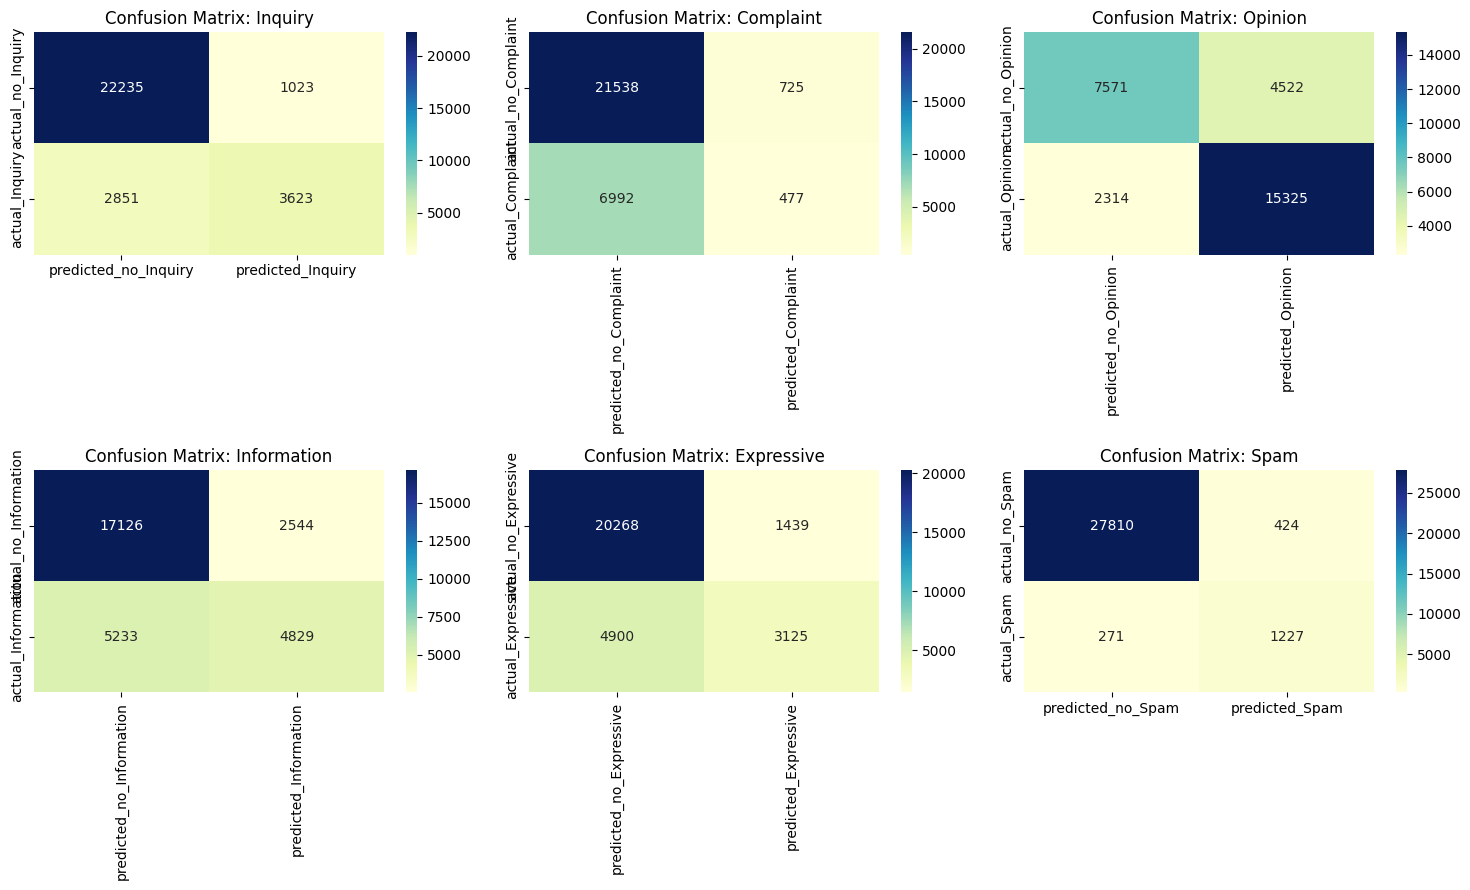


Overall Average F1 Score: 0.568



In [46]:
lr_f1_scores = evaluate_model("Logistic Regression", y_test, y_pred_lr, label_cols)

## 5.5 Random Forest Evaluation

We evaluate the Random Forest model across all intent categories to assess individual precision, recall, and F1-score balances.

RANDOM FOREST EVALUATION

--- Category: Inquiry ---
[21641  1617]
[2035  4439]
Accuracy:  0.877
Precision:  0.733
Recall:  0.686
F1 Score:  0.709

--- Category: Complaint ---
[22059  204]
[6951  518]
Accuracy:  0.759
Precision:  0.717
Recall:  0.069
F1 Score:  0.126

--- Category: Opinion ---
[7424  4669]
[1822  15817]
Accuracy:  0.782
Precision:  0.772
Recall:  0.897
F1 Score:  0.83

--- Category: Information ---
[17304  2366]
[4345  5717]
Accuracy:  0.774
Precision:  0.707
Recall:  0.568
F1 Score:  0.63

--- Category: Expressive ---
[20566  1141]
[5167  2858]
Accuracy:  0.788
Precision:  0.715
Recall:  0.356
F1 Score:  0.475

--- Category: Spam ---
[27841  393]
[256  1242]
Accuracy:  0.978
Precision:  0.76
Recall:  0.829
F1 Score:  0.793


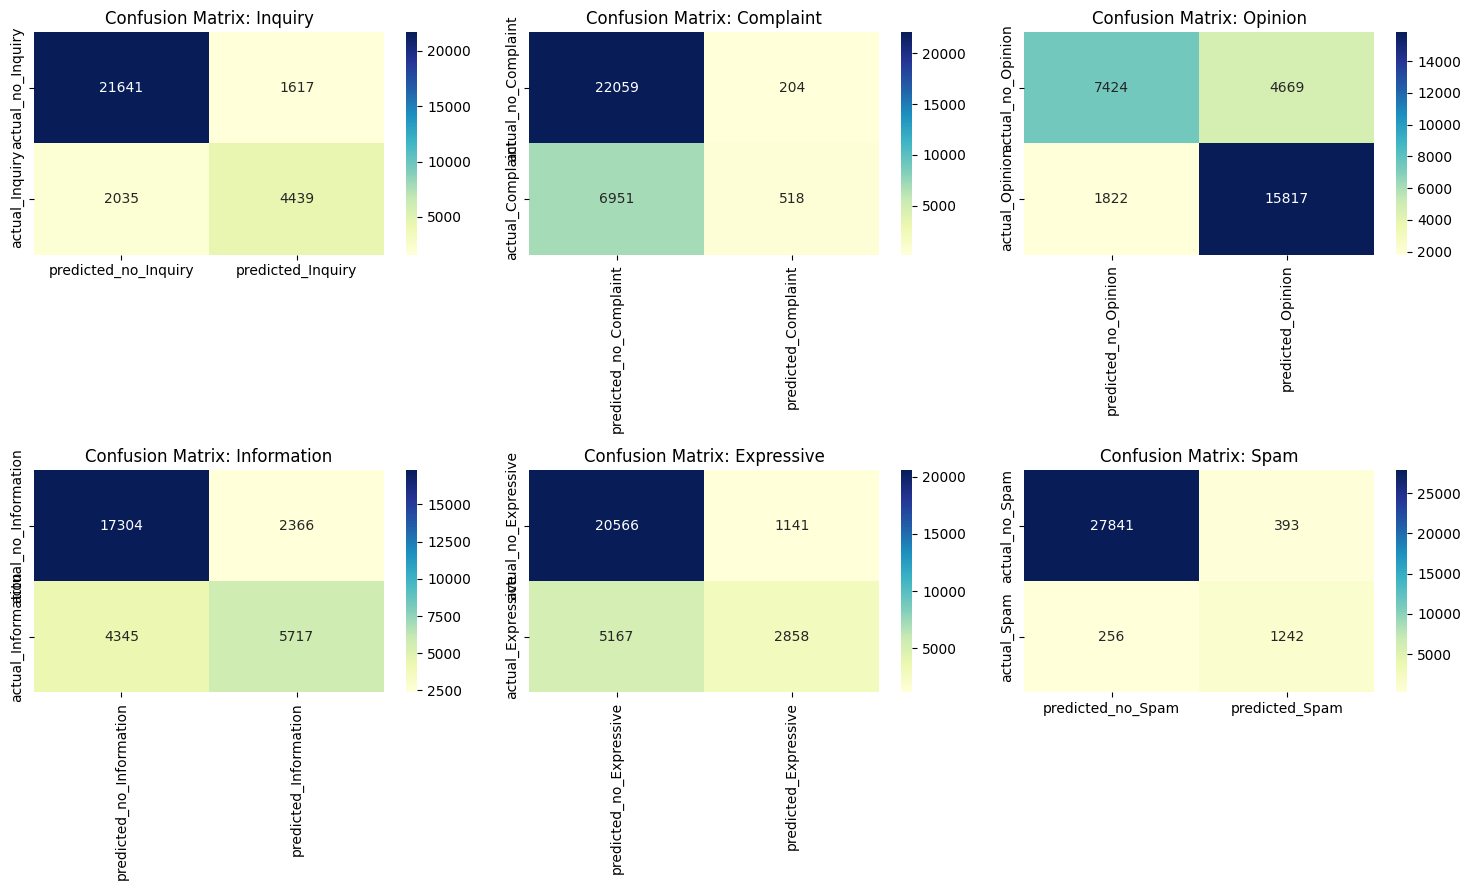


Overall Average F1 Score: 0.594



In [47]:
rf_f1_scores = evaluate_model("Random Forest", y_test, y_pred_rf, label_cols)

## 5.6 Model Comparison

We summarize and compare the F1-scores of both models across all communicative intent categories in a single comparison table to identify the best-performing architecture.

MODEL COMPARISON SUMMARY


,Category,Logistic Regression F1,Random Forest F1,Difference (RF - LR)
0,Inquiry,0.652,0.709,+0.057
1,Complaint,0.110,0.126,+0.016
2,Opinion,0.818,0.830,+0.012
3,Information,0.554,0.630,+0.076
4,Expressive,0.496,0.475,-0.021
5,Spam,0.779,0.793,+0.014


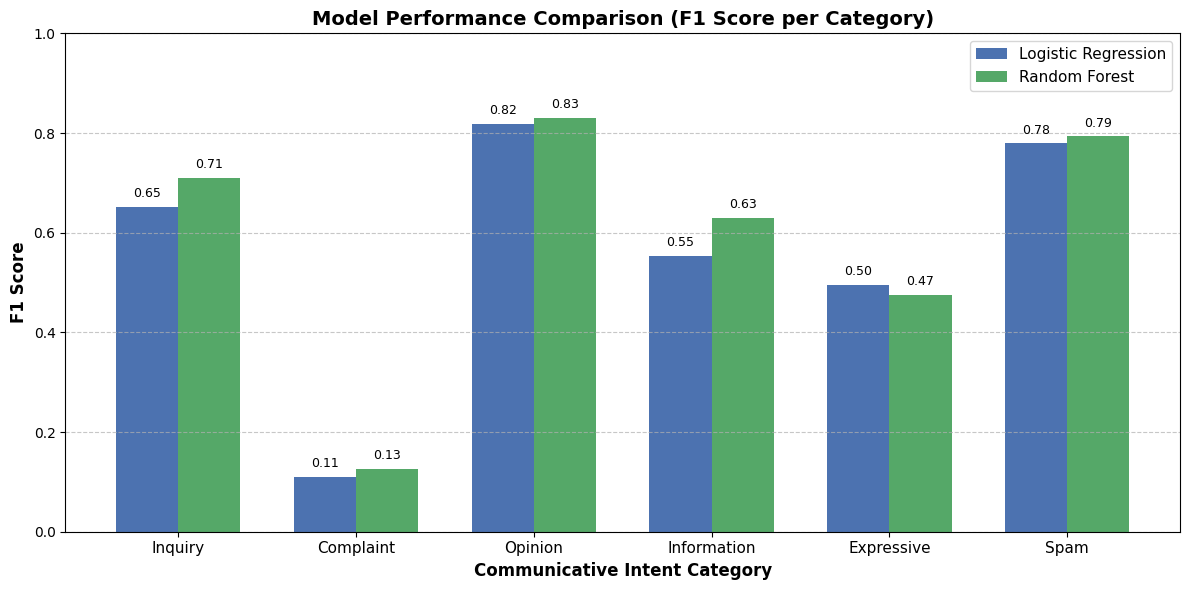

In [48]:
# Summary Comparison Table
print("=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
display(
    pd.DataFrame(
        {
            "Category": label_cols,
            "Logistic Regression F1": lr_f1_scores,
            "Random Forest F1": rf_f1_scores,
            "Difference (RF - LR)": np.array(rf_f1_scores) - np.array(lr_f1_scores),
        }
    ).style.format(
        {
            "Logistic Regression F1": "{:.3f}",
            "Random Forest F1": "{:.3f}",
            "Difference (RF - LR)": "{:+.3f}",
        }
    )
)

# Side-by-Side Presentation Bar Chart
plt.figure(figsize=(12, 6))
x = np.arange(len(label_cols))
width = 0.35

plt.bar(
    x - width / 2, lr_f1_scores, width, label="Logistic Regression", color="#4C72B0"
)
plt.bar(x + width / 2, rf_f1_scores, width, label="Random Forest", color="#55A868")

plt.xlabel("Communicative Intent Category", fontsize=12, fontweight="bold")
plt.ylabel("F1 Score", fontsize=12, fontweight="bold")
plt.title(
    "Model Performance Comparison (F1 Score per Category)",
    fontsize=14,
    fontweight="bold",
)
plt.xticks(x, label_cols, fontsize=11)
plt.ylim(0, 1.0)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add data labels on top of each bar
for i in range(len(label_cols)):
    plt.text(
        x[i] - width / 2,
        lr_f1_scores[i] + 0.02,
        f"{lr_f1_scores[i]:.2f}",
        ha="center",
        fontsize=9,
    )
    plt.text(
        x[i] + width / 2,
        rf_f1_scores[i] + 0.02,
        f"{rf_f1_scores[i]:.2f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# 6.0 Predict Unseen Data

In this section, we deploy our saved feature extractors and trained classifiers to predict multi-label communicative intents on brand-new, unseen online forum posts in real time.

## 6.1 Load Saved Models from Joblib

We load the pre-trained FastText embedding model, Logistic Regression classifier, and Random Forest classifier from serialized Joblib disk files into memory.

In [49]:
# Load all saved model artifacts and feature extractors from joblib
loaded_ft = joblib.load("fasttext_model.joblib")
loaded_tfidf = joblib.load("tfidf_vectorizer.joblib")
loaded_lr = joblib.load("logistic_regression_model.joblib")
loaded_rf = joblib.load("random_forest_model.joblib")

# Build the TF-IDF lookup dictionary and default IDF weight for inference
loaded_idf_dict = dict(zip(loaded_tfidf.get_feature_names_out(), loaded_tfidf.idf_))
loaded_default_idf = float(np.mean(loaded_tfidf.idf_))

print("=" * 65)
print("ALL MODEL ARTIFACTS LOADED SUCCESSFULLY")
print("=" * 65)
print(f"FastText Model Vocab Size : {len(loaded_ft.wv.key_to_index):,}")
print(f"TF-IDF Feature Vocab Size : {len(loaded_idf_dict):,}")
print(f"Default (Mean) IDF Weight : {loaded_default_idf:.4f}")
print("Logistic Regression Model : Ready")
print("Random Forest Model       : Ready")
print("=" * 65)

ALL MODEL ARTIFACTS LOADED SUCCESSFULLY
FastText Model Vocab Size : 28,689
TF-IDF Feature Vocab Size : 26,773
Default (Mean) IDF Weight : 9.9185
Logistic Regression Model : Ready
Random Forest Model       : Ready


## 6.2 Interactive Real-Time Forum Comment Prediction Loop

We provide an interactive inference loop that feeds user-input Manglish/Malay forum text through the end-to-end preprocessing pipeline and displays real-time intent predictions.

In [ ]:
print("=" * 65)
print("INTERACTIVE UNSEEN FORUM INTENT PREDICTOR")
print("Type 'exit' or 'q' to stop.")
print("=" * 65)

while True:
    user_input = input("\nEnter forum comment: ").strip()

    if user_input.lower() in ["exit", "q", "quit"]:
        print("Exiting prediction loop. Done!")
        break

    if not user_input:
        print("Input cannot be empty.")
        continue

    # Pipeline stages
    text = remove_quotes(user_input)
    text = remove_lowyat_edit_signatures(text)
    text = mask_urls(text)
    text = mask_phone_numbers(text)
    text = mask_prices(text)
    text = mask_times(text)
    text = mask_dates(text)
    text = convert_emojis(text)
    text = to_lower(text)
    text = normalize_apostrophes(text)
    text = strip_non_latin(text)
    text = reduce_elongated(text)

    sentences = tokenize_sentences(text)
    norm_en = [normalize_slang_bulletproof(s) for s in sentences]
    norm_my = [normalize_malay_slang_bulletproof(s) for s in norm_en]
    norm_contractions = [normalize_contractions(s) for s in norm_my]

    raw_word_tokens = [tokenize_words(s) for s in norm_contractions]
    filtered_tokens = filter_tokens(raw_word_tokens)

    classified_tokens = classify_post_lang(filtered_tokens)
    stem_lemma_tokens = process_post_stem_lemma(classified_tokens)
    clean_stopped_tokens = filter_post_stopwords(stem_lemma_tokens)

    tokens = flatten_post_to_tokens(clean_stopped_tokens)

    if tokens:
        vec = extract_tfidf_weighted_vector(
            tokens, loaded_ft, loaded_idf_dict, loaded_default_idf
        ).reshape(1, -1)
    else:
        vec = np.zeros((1, 100))

    lr_pred = loaded_lr.predict(vec)[0]
    rf_pred = loaded_rf.predict(vec)[0]

    lr_results = [label_cols[i] for i, val in enumerate(lr_pred) if val == 1]
    rf_results = [label_cols[i] for i, val in enumerate(rf_pred) if val == 1]

    print("-" * 50)
    print("Cleaned Tokens      :", tokens)
    print("Logistic Regression :", lr_results if lr_results else ["Neutral / None"])
    print("Random Forest       :", rf_results if rf_results else ["Neutral / None"])
    print("-" * 50)

INTERACTIVE UNSEEN FORUM INTENT PREDICTOR
Type 'exit' or 'q' to stop.



Enter forum comment:  i drank 3/4 cup of water


--------------------------------------------------
Cleaned Tokens      : ['drink', 'cawan', 'water']
Logistic Regression : ['Opinion', 'Expressive']
Random Forest       : ['Neutral / None']
--------------------------------------------------



Enter forum comment:  see you 15/08


--------------------------------------------------
Cleaned Tokens      : ['see', 'datetoken']
Logistic Regression : ['Information']
Random Forest       : ['Information']
--------------------------------------------------



Enter forum comment:  rated it 8.50 out of 10


--------------------------------------------------
Cleaned Tokens      : ['rat', '10']
Logistic Regression : ['Complaint', 'Opinion', 'Information']
Random Forest       : ['Information']
--------------------------------------------------



Enter forum comment:  saya tak nak beli ni


--------------------------------------------------
Cleaned Tokens      : ['tak', 'beli', 'no', 'idea']
Logistic Regression : ['Opinion']
Random Forest       : ['Opinion', 'Expressive']
--------------------------------------------------
